# Preparations

## use public packages

In [52]:
import os, time, shelve, joypy
import copy as cp
import numpy as np
import scipy as sp
import pandas as pd
import igraph as ig
import matplotlib.pyplot as plt
import matplotlib.colors as clr
from   numpy import random as rd
from datetime import datetime as dt_

In [53]:
hg19_total_gsz = 2948611470
hg19_chr_sizes = {"1":231223641, "6":170078524,"11":134634058,"16":83378703,"21":40088623,
                  "2":240863511, "7":158970135,"12":133137821,"17":83481871,"22":40181019,
                  "3":198255541, "8":144768136,"13":97983128, "18":80089650, "X":154893034,
                  "4":189962376, "9":122084564,"14":91660769, "19":58440758, "Y":26452288,
                  "5":181358067,"10":133263006,"15":85089576, "20":63944268,"Un":4328403}
hg19_chr_total = {"1":231223641,  "2":472087152,  "3":670342693,  "4":860305069,  "5":1041663136,
                  "6":1211741660, "7":1370711795, "8":1515479931, "9":1637564495,"10":1770827501,
                 "11":1905461559,"12":2038599380,"13":2136582508,"14":2228243277,"15":2313332853,
                 "16":2396711556,"17":2480193427,"18":2560283077,"19":2618723835,"20":2682668103,
                 "21":2722756726,"22":2762937745, "X":2917830779, "Y":2944283067,"Un":2948611470}
chr_list = [str(i) for i in range(1,23)] + ["X", "Y", "Un"]

## self-defined functions

In [54]:
def assign_chr(in_coor, genome_cum_len=hg19_chr_total, genome_size=hg19_total_gsz):
    """
    assign a chromosome to the mutation
    """
    assert in_coor<genome_size
    for i in genome_cum_len.keys():
        if in_coor < genome_cum_len[i]: return f"chr{i:0>2}_{genome_cum_len[i]-in_coor:_>10}"

In [55]:
def construct_convoluted_distribution(neu_pos_rate = 0.300, neu_pos_fit=  0.01, neu_pos_std=0.03,
                                      neu_neg_rate = 0.700, neu_neg_fit= -0.03, neu_neg_std=0.03,
                                      cel_dth_rate = 0.002, cel_dth_fit= -4,    cel_dth_std=0.03,
                                      carcino_rate = 0.002, carcino_fit=  5,    carcino_std=0.03, 
                                      n_xrange = 2001, plot = False):
    """
    construct the stacked probability density 
    util: X___range, Y_combine = construct_convoluted_distribution()
    """
    # set up fit sampling range
    X___range = np.concatenate([np.linspace(cel_dth_fit-3*cel_dth_std, carcino_fit+3*carcino_std, n_xrange)])
    
    # get fitness probability dense function for different contributer
    Y_neu_pos = sp.stats.norm.pdf(X___range, loc=neu_pos_fit, scale=neu_pos_std) * neu_pos_rate  # positive neutral drift
    Y_neu_neg = sp.stats.norm.pdf(X___range, loc=neu_neg_fit, scale=neu_neg_std) * neu_neg_rate  # negative neutral drift
    Y_cel_dth = sp.stats.norm.pdf(X___range, loc=cel_dth_fit, scale=cel_dth_std) * cel_dth_rate  # carcinogenesis
    Y_carcino = sp.stats.norm.pdf(X___range, loc=carcino_fit, scale=carcino_std) * carcino_rate  # cell death
    
    # stack probability dense function together
    Y_combine = Y_neu_pos + Y_neu_neg + Y_cel_dth + Y_carcino
    locs = Y_combine > np.quantile(Y_combine, 0.92) # remove those very close to 0 for efficiency
    X___range = X___range[locs] ; Y_neu_pos = Y_neu_pos[locs] ; Y_neu_neg = Y_neu_neg[locs]
    Y_cel_dth = Y_cel_dth[locs] ; Y_carcino = Y_carcino[locs] ; Y_combine = Y_combine[locs]
    
    if plot:
        # visualize the probability dense function
        fig_hig = 3 ; fig_wid = 18
        fig, (ax1) = plt.subplots(1, 1, figsize=(fig_wid, fig_hig))
        plot_att = {"marker":"o", "linestyle":"solid", "markersize":"3", "linewidth":"1.5"}
        _=ax1.plot(X___range, Y_neu_pos,     c="#10385b", label="positive neutral drift",      **plot_att)
        _=ax1.plot(X___range, Y_neu_neg,     c="#910c3d", label="negative neutral drift",      **plot_att)
        _=ax1.plot(X___range, Y_cel_dth*50,  c="#184d47", label="carcinogenesis (overscaled)", **plot_att)
        _=ax1.plot(X___range, Y_carcino*50,  c="#c70138", label="mut-cell death (overscaled)", **plot_att)
        _=ax1.plot(X___range, Y_combine/2.5, c="#2e2518", label="combined fitness changes",    **plot_att)
        _=ax1.legend()
    
    Y_combine = Y_combine/Y_combine.sum()
    return X___range, Y_combine

In [56]:
def mutation_contribution(in_fitness):
    """
    evaluate the effect of a mutation
    """
    if   (-0.01 <=in_fitness) & (in_fitness <= 0.01) : return "neutral"
    elif ( 0.01 < in_fitness) & (in_fitness <= 2   ) : return "positive"
    elif (   -2 <=in_fitness) & (in_fitness < -0.01) : return "negative"
    elif      2 < in_fitness                         : return "cancer"
    elif                         in_fitness < -2     : return "death"

In [57]:
class cell:
    def __init__(self, mot=None, dob=None, gen=None, fit=1, cft=1, dft=0, mut=[]):
        self.mot = mot  # mother of this cell
        self.dob = dob  # date of birth
        self.fit = fit  # fitness, i.e., duplication rate
        self.cft = cft  # cumulative fitness in an experiment
        self.dft = dft  # delta fitness after mutation
        self.gen = gen  # generation
        self.mut = mut  # carried mutations dictionary
        
    def __repr__(self):
        return f"gen {self.gen}, born by {self.mot} at {self.dob}"
    
    def mutate(self, X___range, Y_combine, Mut_Dict, genome_size=hg19_total_gsz, n=30):
        '''
        X___range: 
        Y_combine: fitness distribution
         Mut_Dict: all mutations in an experiment, pd.Dataframe
                n: of mutations accumulated per cell division
        fit_min, fit_max: accepted fitness range
        '''
        # first sample non-redundant mutations
        new_mut=np.array([1,1])
        while len(set(self.mut + list(new_mut))) < len(self.mut)+len(new_mut):
            new_mut = [i for i in rd.randint(1, genome_size+1, size=n)]
        self.mut = self.mut + new_mut
        # then calculate updated fitness
        for mut_i in new_mut:
            if mut_i in Mut_Dict:  # directly transfer from the Mut_Dict
                self.dft = self.dft + Mut_Dict[mut_i]["fitness"]
            else:
                delta_fit = rd.choice(X___range, p=Y_combine)
                self.dft = self.dft + delta_fit
                Mut_Dict[mut_i] = {"name":assign_chr(mut_i), "fitness":delta_fit, "gen":self.gen, "f_all":0, "f_end":0, "f_liv":0}

In [58]:
def initialize_a_cell(nsomatic):
    """
    create a cell with initial mutations
    """
    init_mut = {assign_chr(i):[ "innate", 0, 0, 0, 0, 0] for i in rd.randint(1, hg19_total_gsz, nsomatic)}
    init_mut["Germline_mut"] = ["innate", 0, 0, 0, 0, 0]
    new_cell = cell("nature", 0, gen=0, fit=1, mut=init_mut)
    return new_cell

def init_n_cell_m_mut(n, m):
    """
    create n cell with m initial mutations
    """
    CellPool = {0:cell(mot=0, dob=0, gen=0, fit=1, cft=0, mut=[])}
    CellPool.update({i:cell(mot=0, dob=0, gen=1, fit=1, cft=1, mut=list(rd.randint(1, hg19_total_gsz, m))) for i in range(1, n+1)})
    Cells2Go = list(CellPool.keys())[1:]
    Mut_Pool = {}
    for cell_i in range(1, len(CellPool)):
        for muta_j in CellPool[cell_i].mut:
            Mut_Pool[muta_j] = {"name":assign_chr(muta_j), "fitness":0, "gen":0, "f_all":0, "f_end":0, "f_liv":0}
    return CellPool, Cells2Go, Mut_Pool

In [59]:
def update_fitness(cell_1_fit, cell_2_fit, update_mode="natural", Bias_Pos=0.1, Bias_Neg=-0.1):
    """
    update the fitness of a cell
    natural: do nothing, use the automatically generated effect
    neurtal: make the cell fitness to 1
    biased:  make the cell fitness more different
    """
    if update_mode not in {"natural", "neutral", "biased"}:
        update_mode = "natural"
    if   update_mode=="natural": pass
    elif update_mode=="neutral": cell_1_fit = cell_2_fit = 1
    elif update_mode== "biased": 
        if   cell_1_fit > cell_2_fit: cell_1_fit *= max((1+Bias_Pos),0.1) ; cell_2_fit *= max((1+Bias_Neg),0.1)
        elif cell_1_fit < cell_2_fit: cell_2_fit *= max((1+Bias_Pos),0.1) ; cell_1_fit *= max((1+Bias_Neg),0.1)
    return cell_1_fit, cell_2_fit

def fitness_model(Fit_dtc1, Fit_dtc2, Gen__now, Brk__Pnt=15, Bias_Pos=0.1, Bias_Neg=-0.1, Fit_uplm=5, Fit_lwlm=0.001, EvoModel="complete_neutral"):
    """
    supervise the development of tumor
    """
    Bias_Pos = abs(Bias_Pos) ; Bias_Neg = -abs(Bias_Neg)
    if   EvoModel=="complete_neutral":
        Fit_dtc1,Fit_dtc2 = update_fitness(Fit_dtc1, Fit_dtc2, update_mode="neutral")
    elif EvoModel=="branching_then_neutral":
        if Gen__now<=Brk__Pnt: Fit_dtc1,Fit_dtc2 = update_fitness(Fit_dtc1, Fit_dtc2, update_mode="biased", Bias_Pos=Bias_Pos, Bias_Neg=Bias_Neg)
        else:                  Fit_dtc1,Fit_dtc2 = update_fitness(Fit_dtc1, Fit_dtc2, update_mode="neutral")
    elif EvoModel=="continue_branching":
        if Gen__now<=Brk__Pnt: Fit_dtc1,Fit_dtc2 = update_fitness(Fit_dtc1, Fit_dtc2, update_mode="biased", Bias_Pos=Bias_Pos, Bias_Neg=Bias_Neg)
        else:                  Fit_dtc1,Fit_dtc2 = update_fitness(Fit_dtc1, Fit_dtc2, update_mode="biased", Bias_Pos=Bias_Pos*-2, Bias_Neg=Bias_Neg*5)
    else: 
        print("input model unidentified, default to natural, i.e. no modifications of cell fitness.")
    return min(max(Fit_dtc1,Fit_lwlm),Fit_uplm), min(max(Fit_dtc2,Fit_lwlm),Fit_uplm)

In [60]:
def cell_division(ID_par_c, Cell_par, Elapse_t, Gen__now, Mut_Pool, X___range, Y_combine, Daughter, 
                  EvoModel="branching_then_neutral", Brk__Pnt=9, Bias_Pos=0, Bias_Neg=0.25, Fit_uplm=500, Cell_Sort="random"):
    """
    divide one cell into two subsidiary cells
    """
    N_avgmut = 100 - Gen__now**1.3; N_avgmut = min(180, max(40, N_avgmut))
    Cell_Dt1 = cell(ID_par_c, Elapse_t, Gen__now, Cell_par.fit, Cell_par.cft, mut=Cell_par.mut.copy())
    Cell_Dt2 = cell(ID_par_c, Elapse_t, Gen__now, Cell_par.fit, Cell_par.cft, mut=Cell_par.mut.copy())
    Cell_Dt1.mutate(X___range, Y_combine, n=rd.poisson(N_avgmut), Mut_Dict=Mut_Pool)
    Cell_Dt2.mutate(X___range, Y_combine, n=rd.poisson(N_avgmut), Mut_Dict=Mut_Pool)
    ### update fitness here
    Fit_dtc1, Fit_dtc2 = Cell_Dt1.fit + Cell_Dt1.dft, Cell_Dt2.fit + Cell_Dt2.dft
    Fit_dtc1, Fit_dtc2 = fitness_model(Fit_dtc1, Fit_dtc2, Gen__now, Brk__Pnt=Brk__Pnt, EvoModel=EvoModel, Bias_Pos=0, Bias_Neg=0.25, Fit_uplm=500)
    Cell_Dt1.fit = Fit_dtc1 ; Cell_Dt1.cft += Cell_Dt1.fit ; Cell_Dt2.fit = Fit_dtc2 ; Cell_Dt2.cft += Cell_Dt2.fit
    ID_DTC_1, ID_DTC_2 = Daughter[0], Daughter[1]
    if       Cell_Sort ==        "random": return ID_DTC_1, ID_DTC_2, Cell_Dt1, Cell_Dt2
    else:
        if   Cell_Sort == "smaller_first": 
            if Cell_Dt1.fit<Cell_Dt2.fit:  return ID_DTC_1, ID_DTC_2, Cell_Dt1, Cell_Dt2
            else:                          return ID_DTC_1, ID_DTC_2, Cell_Dt2, Cell_Dt1
        elif Cell_Sort ==  "larger_first":
            if Cell_Dt1.fit>Cell_Dt2.fit:  return ID_DTC_1, ID_DTC_2, Cell_Dt1, Cell_Dt2
            else:                          return ID_DTC_1, ID_DTC_2, Cell_Dt2, Cell_Dt1
    return Cell_Dt1, Cell_Dt2

In [61]:
def get_branch_size(edge_df, vert_df, sorc_node):
    """
    get the branch size (branch_sz; # of sub nodes)
    in parental tree: par__tree, 
    from source node: sorc_node
    to target branch: to_branch
    """
    node_2_go = [sorc_node]
    branch_sz = 1
    while len(node_2_go)>0:
        work_node = node_2_go.pop(0)
        if vert_df.loc[work_node, "bch_sz"]>0:
            branch_sz += vert_df.loc[work_node, "bch_sz"]
        else:
            sub__node = edge_df.loc[edge_df["source"]==work_node, "target"].tolist()
            while work_node in sub__node: sub__node.remove(work_node)
            branch_sz += len(sub__node)
            node_2_go = sub__node + node_2_go
    return branch_sz

In [62]:
def build_a_graph(CellPool, Brk__Pnt=float("Inf"), fin_cell=None, nsample=100):
    """
    This function build a evolutionary graph based on the input division experiment cell pools.
    In a neutral evolution experiment, also provide a time point on which it was set to neutral so that 
    neutrally evolved cells are marked gray.
    """
    #################################################################################################
    ### initialize a graph and insert cell divisions
    #################################################################################################
    Tree_gh = ig.Graph()
    Tree_gh.add_vertices(list(CellPool.keys()))
    for i in CellPool:
        if CellPool[i].mot != i:
            try:    Tree_gh.add_edge(Tree_gh.vs.find(name=CellPool[i].mot), Tree_gh.vs.find(name=i))
            except: pass
            if i%100==0: print(f"\rconnecting cell {i} to the graph, {len(CellPool)-i} to go.{' '*20}", end="")
    Tree_vs, Tree_es = Tree_gh.get_vertex_dataframe(), Tree_gh.get_edge_dataframe()
    # add some characteristics
    Tree_vs["color"]="grey" ; Tree_vs.loc[0, "color"]="black"
    Tree_vs["dist"] = Tree_gh.distances(source=0)[0]
    
    #################################################################################################
    ### calculate branch width using sub-tree sizes
    #################################################################################################
    Tree_vs["bch_sz"] = 0
    for i in Tree_vs.index[::-1]:
        Tree_vs.loc[i, "bch_sz"] = get_branch_size(Tree_es, Tree_vs, i)
    Tree_vs["bch_sz"] = (np.log(Tree_vs["bch_sz"])+0.1).tolist()
    Tree_vs.loc[0, "bch_sz"] *= 1.5
    Tree_es["eg_wid"] = Tree_vs.loc[Tree_es["target"],"bch_sz"].tolist()
    
    ### color branches by sub-tree sizes
    cols = ["#00004d","#045993","#616161","#b40c0d","#800000"]
    cmap = clr.LinearSegmentedColormap.from_list('custom blue', cols, N=1000)
    Tree_vs["fitness"] = [CellPool[i].fit for i in Tree_vs.index]
    Tree_es["fitness"] = Tree_vs.loc[Tree_es["source"],"fitness"].tolist()
    Tree_es["fit_col"] = [clr.rgb2hex(cmap((i-0.001)/2)) for i in Tree_es["fitness"]]
    Loc_Neut = (Tree_vs.loc[Tree_es["source"], "dist"]>=Brk__Pnt).tolist()
    Tree_es["stg_col"] = "#424242"
    Tree_es.loc[Loc_Neut,"stg_col"] = "#616161"
    #################################################################################################
    ### Sampling end-node cells as if doing a scDNA-seq experiment
    #################################################################################################
    if fin_cell:
        # draw some samples
        sample_some_cells = rd.choice(fin_cell, nsample)
        sample_some_edges = [i in sample_some_cells for i in Tree_es["target"]]
        Tree_vs["sampled"] = 0 ; Tree_vs.loc[sample_some_cells, "sampled"] = 1
        Tree_vs.loc[sample_some_cells, "bch_sz"] *= 5  ; Tree_vs.loc[sample_some_cells,   "color"] = "#ffcc04"
        Tree_es.loc[sample_some_edges, "eg_wid"] *= 10 ; Tree_es.loc[sample_some_edges, "fit_col"] = "#ffcc04"
        Tree_vs["node_size"] = 0
        Tree_vs.loc[fin_cell, "node_size"] = 0.3
        Tree_vs.loc[Tree_vs["sampled"]==1, "node_size"] = 1.5
        Tree_vs["finlabel"] = " "
        Tree_vs.loc[fin_cell, "finlabel"] = Tree_vs.loc[fin_cell, "name"] 
    return Tree_gh, Tree_vs, Tree_es

In [63]:
def plot_graph_structure(CellPool, g, Tree_vs, Tree_es, labels=False, save_to=None):
    # layout as a tree
    layout = g.layout_reingold_tilford(root=[0])
    
    # update tree depth by different cell features
    coor_t = [[layout[i][0], -CellPool[i].dob] for i in range(len(layout))]       # y coordinates by simulated time
    coor_g = [[layout[i][0], -CellPool[i].gen] for i in range(len(layout))]       # y coordinates by generation
    coor_f = [[layout[i][0], -CellPool[i].cft] for i in range(len(layout))]       # y coordinates by fitness
    coor_m = [[layout[i][0], -len(CellPool[i].mut)] for i in range(len(layout))]  # y coordinates by mutation burden
    
    # scale tree depth by min-max normalization
    X__scale = max([i[0] for i in coor_t])-min([i[0] for i in coor_t])
    Yt_scale = max([i[1] for i in coor_t])-min([i[1] for i in coor_t])
    Yg_scale = max([i[1] for i in coor_g])-min([i[1] for i in coor_g])
    Yf_scale = max([i[1] for i in coor_f])-min([i[1] for i in coor_f])
    Ym_scale = max([i[1] for i in coor_m])-min([i[1] for i in coor_m])
    coor_t = [[i[0]/X__scale*100,i[1]/Yt_scale*60] for i in coor_t]
    coor_g = [[i[0]/X__scale*100,i[1]/Yg_scale*60] for i in coor_g]
    coor_f = [[i[0]/X__scale*100,i[1]/Yf_scale*60] for i in coor_f]
    coor_m = [[i[0]/X__scale*100,i[1]/Ym_scale*60] for i in coor_m]
    
    # plot the tree
    fig_wid = 6 ; fig_hig = 16
    fig, axs = plt.subplots(1,4,figsize=(fig_hig,fig_wid))
    img_pars = {"vertex_size":Tree_vs["bch_sz"]/3, "vertex_color":Tree_vs["color"], "edge_width":Tree_es["eg_wid"], "edge_color":Tree_es["fit_col"]}
    if labels == True:
        ig.plot(g, layout=coor_t, target=axs[0], vertex_label=[round(CellPool[i].dob,3) for i in range(len(layout))], **img_pars) ; axs[0].title.set_text("plot by time")
        ig.plot(g, layout=coor_g, target=axs[1], vertex_label=[round(CellPool[i].gen,3) for i in range(len(layout))], **img_pars) ; axs[1].title.set_text("plot by generation")
        ig.plot(g, layout=coor_f, target=axs[2], vertex_label=[round(CellPool[i].cft,3) for i in range(len(layout))], **img_pars) ; axs[2].title.set_text("plot by fitness")
        ig.plot(g, layout=coor_m, target=axs[3], vertex_label=[  len(CellPool[i].mut)   for i in range(len(layout))], **img_pars) ; axs[3].title.set_text("plot by mutations")
    else:
        ig.plot(g, layout=coor_t, target=axs[0], **img_pars) ; axs[0].title.set_text("plot by time")
        ig.plot(g, layout=coor_g, target=axs[1], **img_pars) ; axs[1].title.set_text("plot by generation")
        ig.plot(g, layout=coor_f, target=axs[2], **img_pars) ; axs[2].title.set_text("plot by fitness")
        ig.plot(g, layout=coor_m, target=axs[3], **img_pars) ; axs[3].title.set_text("plot by mutations")
    if save_to:
        plt.savefig(save_to, format="pdf", bbox_inches="tight")
    plt.show()

In [64]:
def plot_bulk_VAF(Mut_Bulk, raw_ylim=100, lg2_ylim=100, rcp_ylim=100):
    """
    plot the VAF distribution
    1. raw VAF
    2. log2 normalized VAF
    3. reciprocal VAF
    """
    fig_wid = 16
    fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=(16,8))
    threshold = 1/2**9
    filtering = Mut_Bulk["vaf"]>threshold
    # 
    hist_1 = ax1.hist(        Mut_Bulk.loc[:, "vaf"],  bins=np.linspace(  0,    1, 501)) ; 
    hist_2 = ax2.hist(np.log2(Mut_Bulk.loc[:, "vaf"]), bins=np.linspace(-15,    0, 501)) ; 
    hist_3 = ax3.hist(      1/Mut_Bulk.loc[:, "vaf"],  bins=np.linspace(  0, 1200, 501)) ; 
    ax1.set_ylim(0,raw_ylim) ; ax1.set_title("raw VAF") ; 
    ax2.set_ylim(0,lg2_ylim) ; ax2.set_title("log2VAF") ; 
    ax3.set_ylim(0,rcp_ylim) ; ax3.set_title(  "1/VAF") ; 
    ax1.vlines(        threshold,  0, raw_ylim, color="red") ; ax1.vlines(        0.5,  0, raw_ylim, color="green")
    ax2.vlines(np.log2(threshold), 0, lg2_ylim, color="red") ; ax2.vlines(np.log2(0.5), 0, lg2_ylim, color="green")
    ax3.vlines(      1/threshold,  0, rcp_ylim, color="red") ; ax3.vlines(      1/0.5,  0, rcp_ylim, color="green")

In [121]:
def run_KS_test(Tree_vs, CellPool, Mut_Bulk, MeanDetc=250, plot=True):
    """
    run Kolmogorov–Smirnov test between 
    """
    # initial parameters
    CellSngl = Tree_vs.index[Tree_vs["sampled"]==1]
    n_sgcell = len(CellSngl)
    tot_iter = int(n_sgcell*(n_sgcell-1)/2)
    # prapare variables
    dist_mtx = pd.DataFrame(np.zeros([len(CellSngl),len(CellSngl)]))
    pval_mtx = pd.DataFrame(np.zeros([len(CellSngl),len(CellSngl)]))
    FDR__mtx = pd.DataFrame(np.zeros([len(CellSngl),len(CellSngl)]))
    FDR_list = pd.DataFrame(np.zeros([tot_iter,3]))
    dist_mtx.index = dist_mtx.columns = pval_mtx.index = pval_mtx.columns = FDR__mtx.index = FDR__mtx.columns = CellSngl
    iters = 0
    if plot:
        fig, ax = plt.subplots(figsize=(18,6))
    # run KS test
    for i in range(n_sgcell):
        cell_i = Mut_Bulk.loc[CellPool[CellSngl[i]].mut,"vaf"]
        cell_i = rd.choice(cell_i, min(rd.poisson(min(MeanDetc, len(cell_i))), len(cell_i)), replace=False).tolist() + [1]
        cell_i.sort()
        if plot:
            ax.scatter(cell_i, np.linspace(0,1,len(cell_i)), marker="+", linewidth=2)
            ax.plot(cell_i, np.linspace(0,1,len(cell_i)), linewidth=2)
        for j in range(i+1, n_sgcell):
            cell_j = Mut_Bulk.loc[CellPool[CellSngl[j]].mut,"vaf"]
            cell_j = rd.choice(cell_j, min(rd.poisson(min(MeanDetc, len(cell_j))), len(cell_j)), replace=False).tolist() + [1]
            KSresult = sp.stats.ks_2samp(cell_i, cell_j, alternative="two-sided")
            dist_mtx.loc[CellSngl[i],CellSngl[j]] = dist_mtx.loc[CellSngl[j],CellSngl[i]] = KSresult[0]
            pval_mtx.loc[CellSngl[i],CellSngl[j]] = pval_mtx.loc[CellSngl[j],CellSngl[i]] = -np.log10(max(KSresult[1], 1e-10))
            FDR_list.iloc[iters,:] = [CellSngl[i], CellSngl[j], max(KSresult[1], 1e-10)]
            iters += 1
            if iters % 40 == 0: 
                print(f"\r{iters/tot_iter*100:0>4.1f}%", end="")
                dist_mtx = dist_mtx.copy() ; FDR_list = FDR_list.copy()
    # reformat FDR list
    FDR_list = FDR_list.sort_values(2)
    inflation = False
    for i in range(FDR_list.shape[0]):
        if not inflation: 
            corrected = FDR_list.iloc[i,2] * (i+1)
            if corrected > 1: corrected = 1 ; inflation = True
        FDR__mtx.loc[FDR_list.iloc[i,0], FDR_list.iloc[i,1]] = FDR__mtx.loc[FDR_list.iloc[i,1], FDR_list.iloc[i,0]] = -np.log10(corrected)
    # show single cell VAF distribution
    
    if plot: ax.set_xlim(0,1) ; plt.show()
    return dist_mtx, pval_mtx, FDR__mtx

# Run simulations

## config experiment

In [66]:
### initialize mutation probability
X___range, Y_combine = construct_convoluted_distribution(neu_pos_rate = 0.470, neu_pos_fit=  0.03, neu_pos_std=0.03,
                                                         neu_neg_rate = 0.530, neu_neg_fit= -0.03, neu_neg_std=0.03,
                                                         cel_dth_rate = 0.005, cel_dth_fit= -4,    cel_dth_std=0.03,
                                                         carcino_rate = 0.005, carcino_fit=  1,    carcino_std=0.03, n_xrange=2001, plot=False)

In [67]:
# config simulations
exp__len =  9 ; cel_lowr = 1500 ; cel_uper =  5000 ; gen_lowr = 5 ; Brk__Pnt=12; Bias_Neg=0.25 ; EvoModel = "complete_neutral"
exp__len = 14 ; cel_lowr = 1200 ; cel_uper = 20000 ; gen_lowr = 5 ; Brk__Pnt=12; Bias_Neg=0.30 ; EvoModel = "branching_then_neutral"
exp__len = 10 ; cel_lowr =  500 ; cel_uper = 50000 ; gen_lowr = 5 ; Brk__Pnt=10; Bias_Neg=0.25 ; EvoModel = "continue_branching"
print(f"# {1+2**exp__len} cells expected under null (neutral) assumption.")

# 1025 cells expected under null (neutral) assumption.


## run simulation

In [68]:
run_ID = dt_.now()
run_ID = f"{EvoModel}_{run_ID.year}_{run_ID.month:0>2}{run_ID.day:0>2}_{run_ID.hour:0>2}{run_ID.minute:0>2}"
iter_num = 0 ; T_ovrall = time.time()
exp_size = 2 ; Gen__max = 0
iterMode = "depth_first" ; Cell_Sort="random"
while (exp_size<cel_lowr) | (cel_uper<exp_size) | (Gen__max<gen_lowr):
    error = ""
    iter_num += 1 ; T_exp_st = time.time()
    Gen__max = 0 ; fin_cell = [] ; exp_size = 2
    print(f"initializing a new iteration {iter_num}", end="")
    CellPool, Cells2Go, Mut_Pool = init_n_cell_m_mut(exp_size, 3000)
    while(len(Cells2Go)>0): # iterate until no cells left
        if exp_size%50==0:  # progress report
            T_exp_ps = time.time()-T_exp_st ; T_p_cell = T_exp_ps/len(CellPool)*1000
            print(f"""\rrun {iter_num:0>2}: {len(CellPool): >4} cells, {len(Cells2Go)} cells remaining, {''
                       }max generation: {Gen__max}, tpc: {T_p_cell: >5.2f} ms.{' '*20}""", end="")
        ID_par_c = Cells2Go.pop(0)
        Elapse_t = CellPool[ID_par_c].dob + 1/CellPool[ID_par_c].fit
        if Elapse_t > exp__len: fin_cell.append(ID_par_c) ; continue  # exceeding experiment range
        Gen__now = CellPool[ID_par_c].gen + 1   # new generation
        Gen__max = max(Gen__max, Gen__now)      # max depth of experiment 
        exp_size = exp_size + 2                 # total cell counts
        if exp_size+len(Cells2Go)>cel_uper:   exp_size=float("inf"); error="too many cells." ; break # avoid too large a dataset

        Daughter = [ID_DTC_1, ID_DTC_2] = [exp_size-1, exp_size]    # IDs of new cells
        if   iterMode == "depth_first":   Cells2Go = Daughter + Cells2Go  # cells to divide
        elif iterMode == "breadth_first": Cells2Go = Cells2Go + Daughter  # cells to divide
        else: print("iter mode unknown, default to breadth first") ; iterMode = "breadth_first" ; Cells2Go = Cells2Go + Daughter
        ID_DTC_1, ID_DTC_2, Cell_Dt1, Cell_Dt2 = cell_division(
            ID_par_c, CellPool[ID_par_c], Elapse_t, Gen__now, Mut_Pool, X___range, Y_combine, Daughter, 
            EvoModel=EvoModel, Brk__Pnt=Brk__Pnt, Bias_Pos=0, Bias_Neg=Bias_Neg, Fit_uplm=500, Cell_Sort="random")
        CellPool[ID_DTC_1], CellPool[ID_DTC_2] = Cell_Dt1, Cell_Dt2

    if   len(CellPool)<cel_lowr: error="too little cells."
    elif Gen__max<gen_lowr: error="too shallow evolution."
    print(f"\rrun {iter_num:0>2} ended after {T_exp_ps: >4.1f} sec for {exp_size}, time/cell: {T_p_cell: >5.1f} ms. {error}{' '*30}")
print(f"\rFinished! after {time.time()-T_ovrall: >4.1f} sec for {iter_num} iterations, totally {len(CellPool)} cells with {Gen__max} generations.")

run 01 ended after  1.8 sec for 970, time/cell:   1.9 ms.                                     
Finished! after  1.8 sec for 1 iterations, totally 971 cells with 68 generations.


In [69]:
Tree_gh, Tree_vs, Tree_es = build_a_graph(CellPool, Brk__Pnt=Brk__Pnt, fin_cell=fin_cell, nsample=50)

building graph
count_sub-nodes                                                  
color_nodes
draw_sc_samples


/tmp/ipykernel_25738/659863061.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.3' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Tree_vs.loc[fin_cell, "node_size"] = 0.3


## plot tree by mutation 

In [70]:
layout = Tree_gh.layout_reingold_tilford(root=[0])  # get fundamental layout
Coor_T_M = [[layout[i][0], -len(CellPool[i].mut)] for i in range(len(layout))]       
X__T_max = max([i[0] for i in Coor_T_M]) ; X__T_min = min([i[0] for i in Coor_T_M]) ; X__T_scl = X__T_max - X__T_min
Ym_T_max = max([i[1] for i in Coor_T_M]) ; Ym_T_min = min([i[1] for i in Coor_T_M]) ; Ym_T_scl = Ym_T_max - Ym_T_min
Coor_T_M = [[i[0]/X__T_scl*100,i[1]/5000*60] for i in Coor_T_M]
X__T_max = X__T_max/X__T_scl*100 ; X__T_min = X__T_min/X__T_scl*100 ; Ym_T_max = Ym_T_max/5000*60 ; Ym_T_min = Ym_T_min/5000*60 ; 

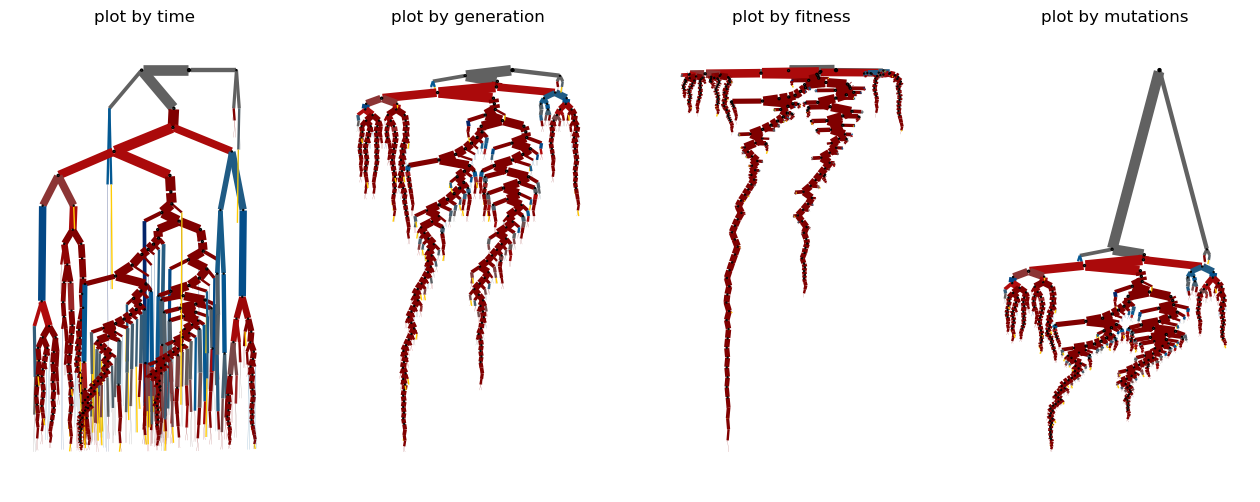

In [71]:
# wthis plot 4 attributes of the tree
plot_graph_structure(CellPool, Tree_gh, Tree_vs.copy(), Tree_es.copy())

## subset some cells

In [72]:
cell_2go = Tree_vs.index[Tree_vs["sampled"]==1].tolist()
keepnode, keepedge = [], []
while len(cell_2go)>0:
    now_cell = cell_2go.pop(0) #; print(now_cell)
    if now_cell in keepnode:
        while now_cell in cell_2go: cell_2go.remove(now_cell)
        continue
    keepnode.append(now_cell)
    now_edge = Tree_es.index[Tree_es["target"] == now_cell].tolist()
    keepedge = keepedge + now_edge
    cell_2go = Tree_es.loc[Tree_es["target"] == now_cell, "source"].tolist() + cell_2go
keepnode = sorted(list(set(keepnode))) ; keepedge = sorted(list(set(keepedge)))
del_node = [i for i in CellPool.keys() if i not in keepnode]

In [73]:
SubT_gh = cp.deepcopy(Tree_gh) ; SubT_gh.delete_vertices(del_node)
SubT_vs = cp.deepcopy(Tree_vs) ; SubT_vs = SubT_vs.iloc[keepnode,:]
SubT_es = cp.deepcopy(Tree_es) ; SubT_es = SubT_es.iloc[keepedge,:]

In [74]:
SubT_vs["coor_x"] = 0
CellSngl = Tree_vs.index[Tree_vs["sampled"]==1]
for i,cell_j in enumerate(CellSngl):
    SubT_vs.loc[cell_j, "coor_x"] = i+1
    
while 0 in SubT_vs["coor_x"].values:
    for i in SubT_vs.index[::-1]:
        if SubT_vs.loc[i,"coor_x"] == 0:
            its_child = SubT_es.loc[Tree_es["source"] == i, "target"].tolist()
            childsloc = [SubT_vs.loc[i,"coor_x"] for i in its_child]
            if 0 in childsloc: pass
            else: SubT_vs.loc[i,"coor_x"] = sum(childsloc)/len(childsloc)

Coor_S_M = [[SubT_vs["coor_x"][i], -len(CellPool[i].mut)] for i in keepnode]       
X__S_max = max([i[0] for i in Coor_S_M]) ; X__S_min = min([i[0] for i in Coor_S_M]) ; X__S_scl = X__S_max - X__S_min
Ym_S_max = max([i[1] for i in Coor_S_M]) ; Ym_S_min = min([i[1] for i in Coor_S_M]) ; Ym_S_scl = Ym_S_max - Ym_S_min
Coor_S_M = [[(i[0]-X__S_min)/X__S_scl*100,i[1]/5000*60] for i in Coor_S_M]
X__S_max = X__S_max/X__S_scl*100 ; X__S_min = X__S_min/X__S_scl*100 ; Ym_S_max = Ym_S_max/5000*60 ; Ym_S_min = Ym_S_min/5000*60 ; 

/tmp/ipykernel_25738/872066267.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '46.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  else: SubT_vs.loc[i,"coor_x"] = sum(childsloc)/len(childsloc)


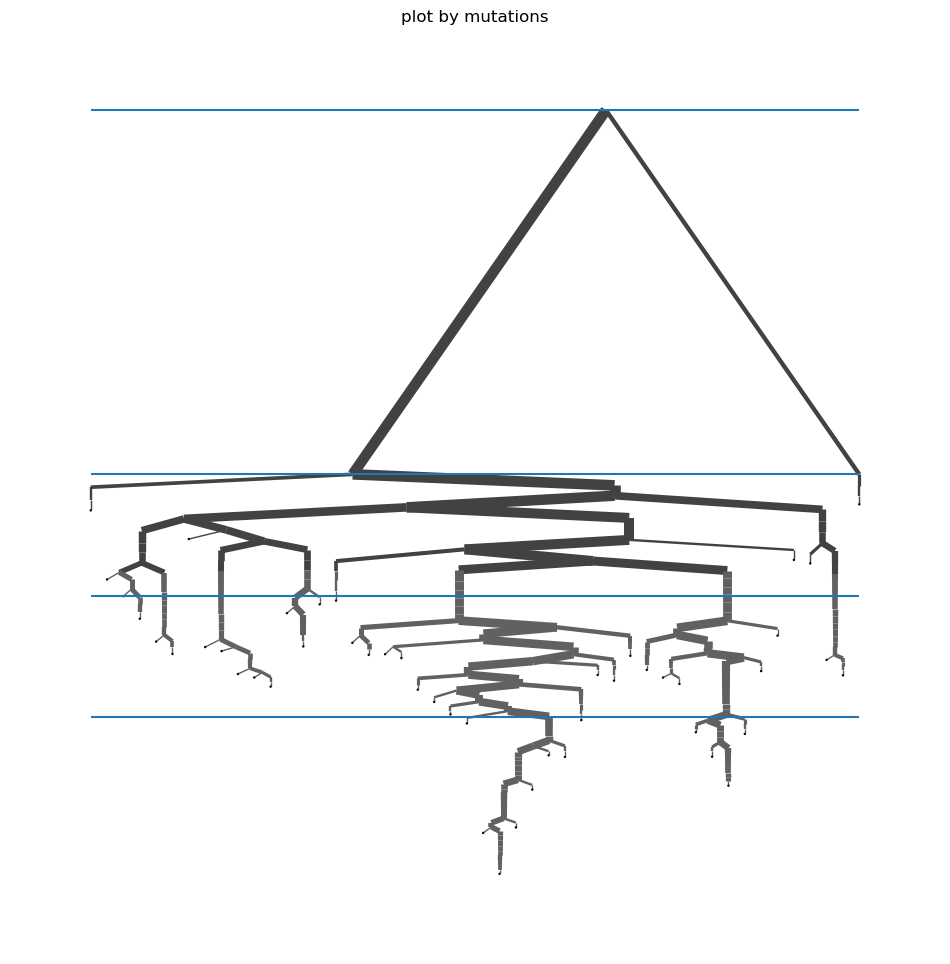

In [75]:
fig, axs = plt.subplots(1,1,figsize=(12,12))
img_pars = {"vertex_size":SubT_vs["node_size"], "vertex_color":SubT_vs["color"], #"vertex_label":SubT_vs["finlabel"], 
            "edge_width":SubT_es["eg_wid"], "edge_color":SubT_es["stg_col"]}
axs.hlines([0,-36, -48, -60], 0, 100)
ig.plot(SubT_gh, layout=Coor_S_M, target=axs, **img_pars) ; axs.title.set_text("plot by mutations")
plt.savefig(f"output/Tree_by_mut_subset_{run_ID}.pdf", format="pdf", bbox_inches="tight")
plt.show()

## fitness variation

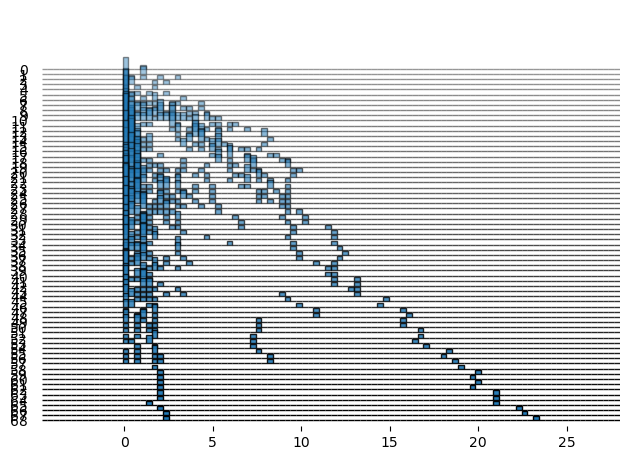

In [76]:
#fig, ax = joypy.joyplot(SubT_vs, by="dist", column = "fitness", fade = True, hist = True, bins = 100)
fig, ax = joypy.joyplot(Tree_vs, by="dist", column = "fitness", fade = True, hist = True, bins = 100)

# Focusing on mutations

In [77]:
Mut_Pool = pd.DataFrame(Mut_Pool).T
for CellIter in CellPool:
    Mut_Pool.loc[CellPool[CellIter].mut, "f_all"] += 1
    if CellPool[CellIter].dob + 1/CellPool[CellIter].fit > exp__len:
        #fin_cell.append(CellIter)
        Mut_Pool.loc[CellPool[CellIter].mut, "f_end"] += 1
        if CellPool[CellIter].fit>0.1:
            Mut_Pool.loc[CellPool[CellIter].mut, "f_liv"] += 1

## sampling bulk

In [78]:
# sampling for bulk
CellBulk = rd.choice(fin_cell, size=min(2000, len(fin_cell)), replace=False)
# mutation set in the sample
Mut_Bulk = set()     
for i, j in enumerate(CellBulk): Mut_Bulk = Mut_Bulk.union(set(CellPool[j].mut)) ; print(f"\r{i}\t{len(CellBulk)-i}", end="")
Mut_Bulk = Mut_Pool.loc[list(Mut_Bulk),:]

485	100

In [79]:
# total mutations that's being sampled
Mut_Bulk.loc[:,"f_smp"] = 0
for i in CellBulk: Mut_Bulk.loc[CellPool[i].mut,"f_smp"] += 1

In [80]:
# account for detection rate
Mut__Vaf = Mut_Bulk.iloc[:,0:0]
for i,cell_id in enumerate(CellBulk):
    Mut__Vaf.loc[:,f"cell_{cell_id}"] = float(0)
    Mut__Vaf.loc[CellPool[cell_id].mut,f"cell_{cell_id}"] = [
        min(max(1e-10,i), 1) for i in rd.normal(0.5,0.25,len(CellPool[cell_id].mut))]
    if i%75==0: Mut__Vaf = Mut__Vaf.copy() ; print(f"\r{i}\t{len(CellBulk)-i}", end="\t\t\t")
cancer_cell_fraction = 1
Mut_Bulk.loc[:,"vaf"] = Mut__Vaf.apply(sum, 1)/len(CellBulk)*cancer_cell_fraction# ; del Mut__Vaf

450	36				

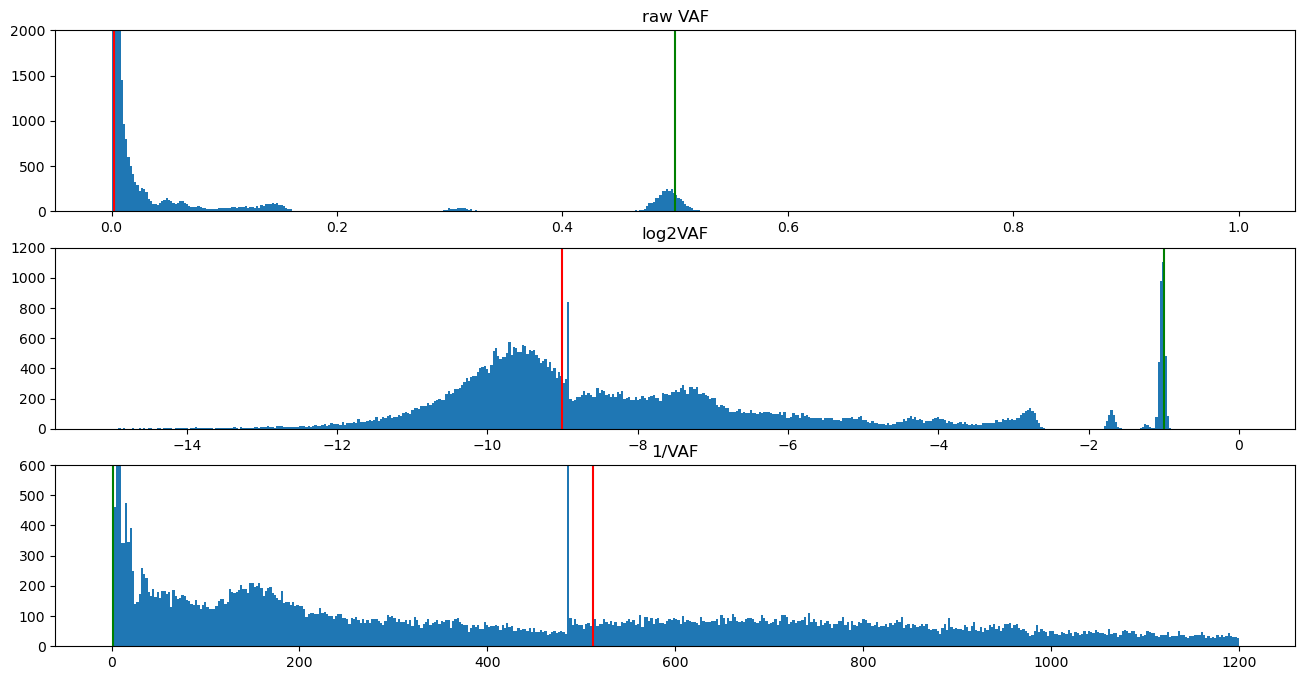

In [81]:
plot_bulk_VAF(Mut_Bulk, raw_ylim=2000, lg2_ylim=1200, rcp_ylim=600)

## sample single cell

In [82]:
sampled = sorted(rd.choice(fin_cell, size=50, replace=False).tolist())
Tree_vs["sampled"] = 0
Tree_vs.loc[sampled, "sampled"] = 1

98.0%

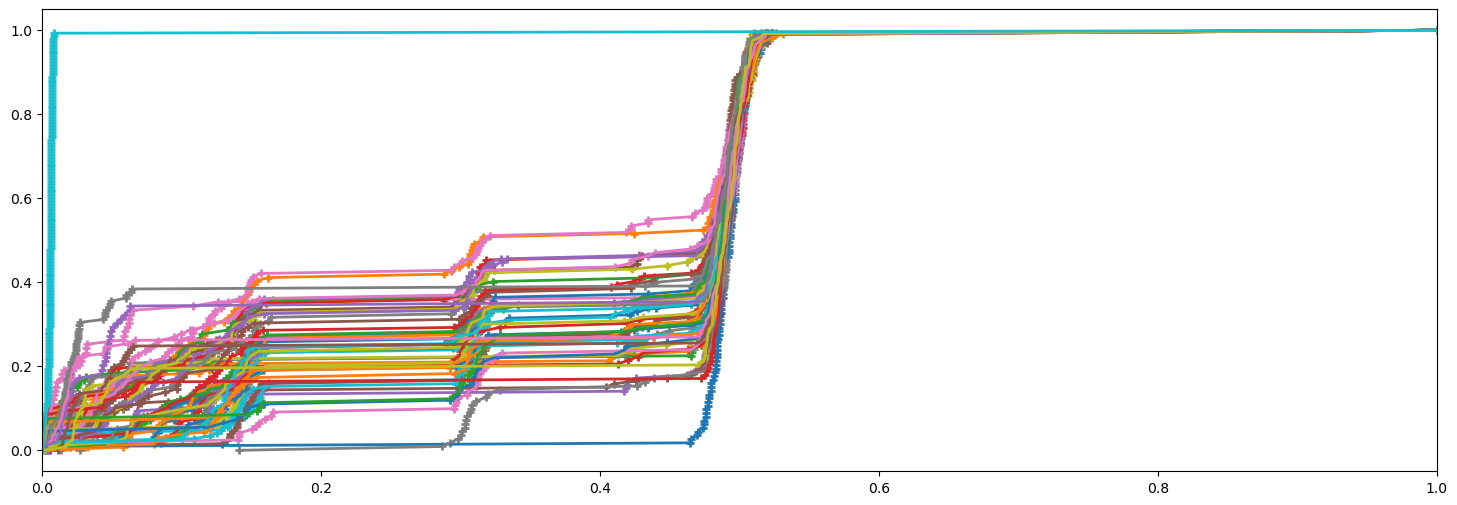

writing dist_mtx_continue_branching_2024_0701_1105_0125_mut.csv
writing FDR__mtx_continue_branching_2024_0701_1105_0125_mut.csv
98.0%

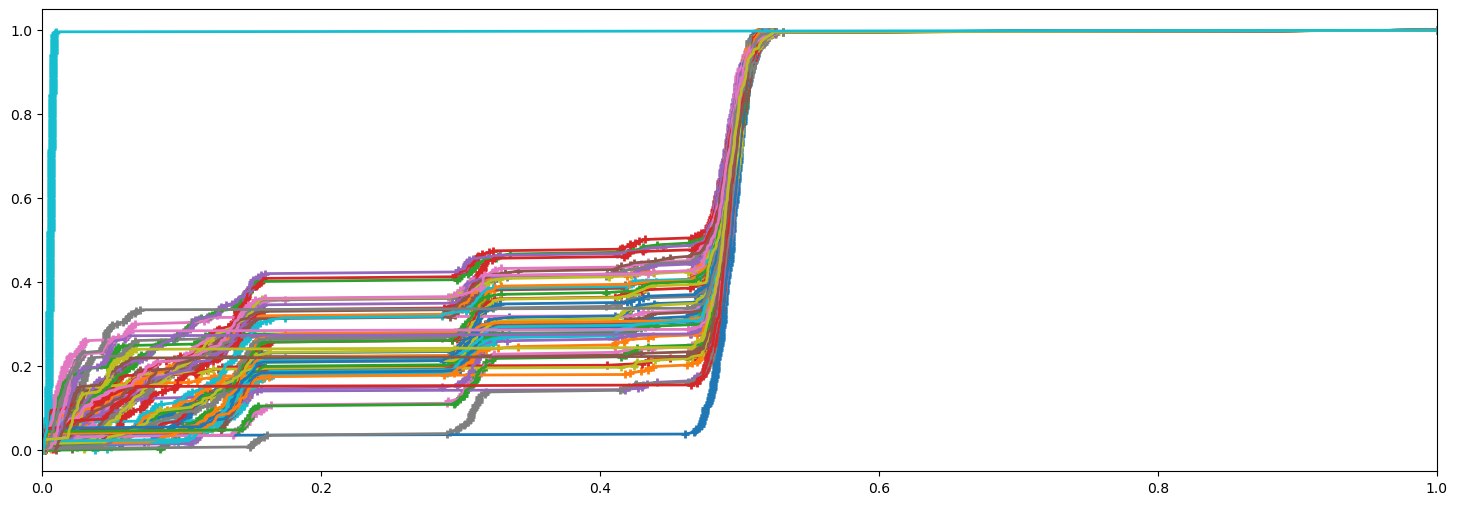

writing dist_mtx_continue_branching_2024_0701_1105_0250_mut.csv
writing FDR__mtx_continue_branching_2024_0701_1105_0250_mut.csv
98.0%

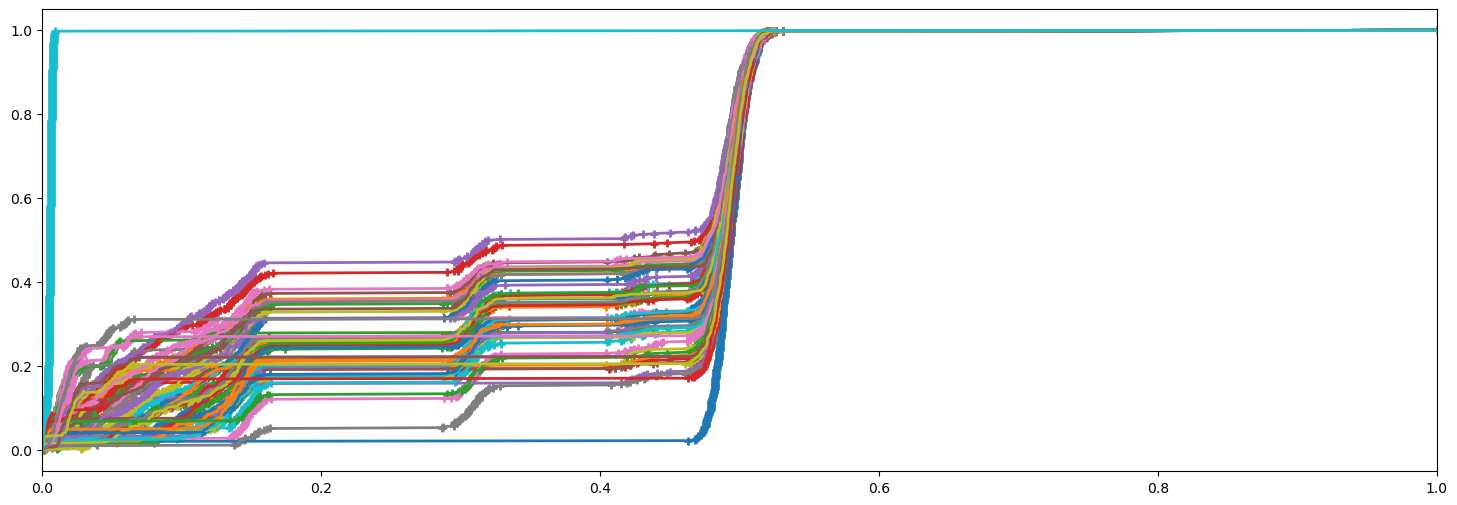

writing dist_mtx_continue_branching_2024_0701_1105_0500_mut.csv
writing FDR__mtx_continue_branching_2024_0701_1105_0500_mut.csv
98.0%

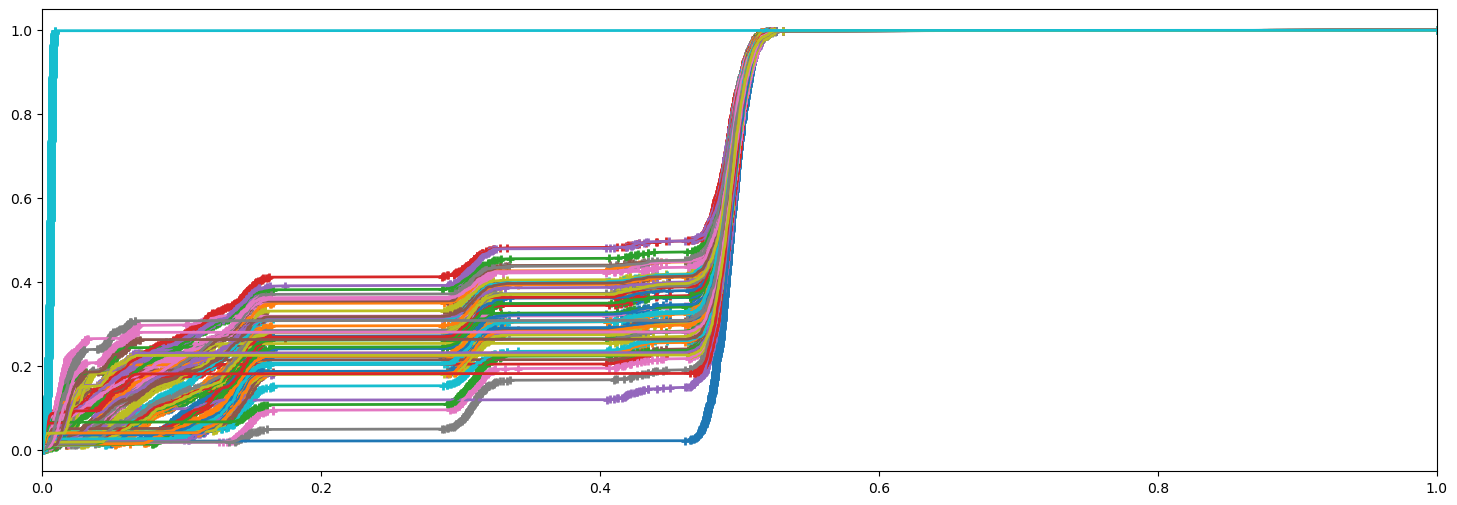

writing dist_mtx_continue_branching_2024_0701_1105_1000_mut.csv
writing FDR__mtx_continue_branching_2024_0701_1105_1000_mut.csv
98.0%

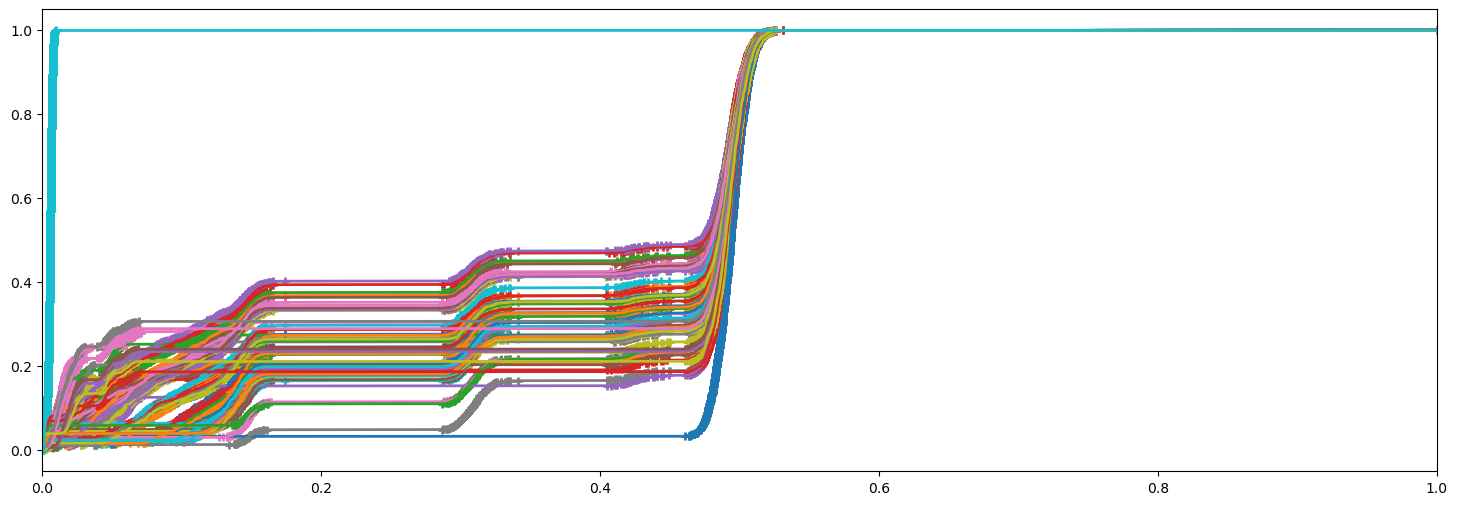

writing dist_mtx_continue_branching_2024_0701_1105_2000_mut.csv
writing FDR__mtx_continue_branching_2024_0701_1105_2000_mut.csv
98.0%

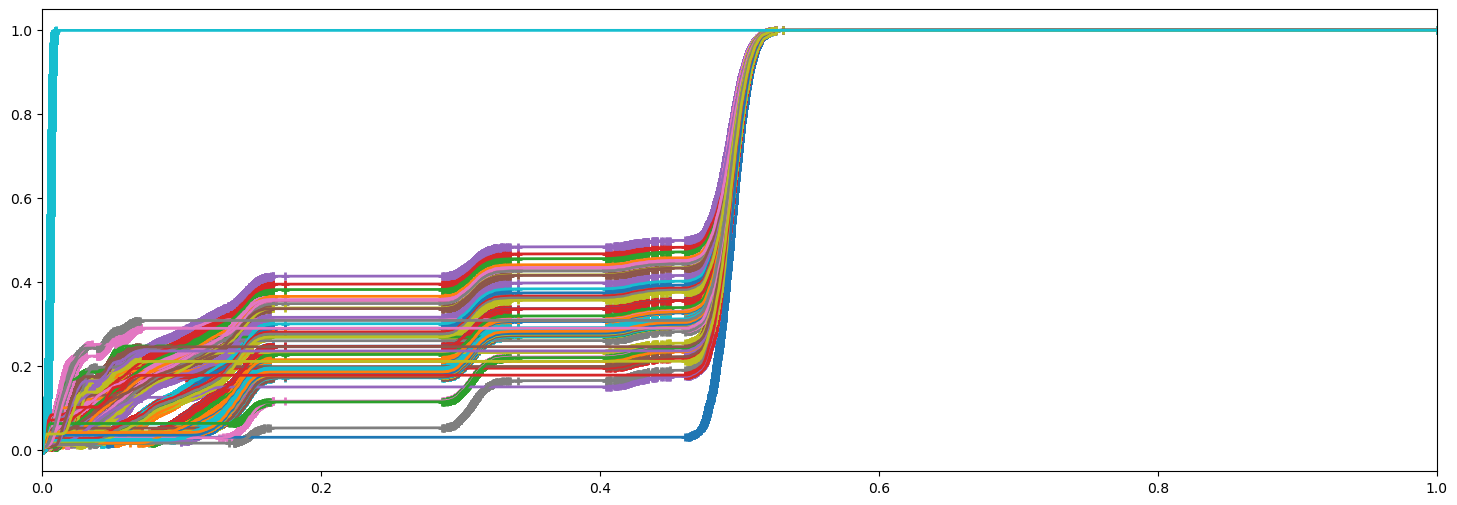

writing dist_mtx_continue_branching_2024_0701_1105_0inf_mut.csv
writing FDR__mtx_continue_branching_2024_0701_1105_0inf_mut.csv


In [122]:
for use_mutation in [125, 250, 500, 1000, 2000, float("inf")]:
    dist_mtx, pval_mtx, FDR__mtx = run_KS_test(Tree_vs, CellPool, Mut_Bulk, MeanDetc=use_mutation, plot=True)
    dist_mtx.to_csv(f"dist_mtx_{run_ID}_{use_mutation:0>4}_mut.csv")
    pval_mtx.to_csv(f"pval_mtx_{run_ID}_{use_mutation:0>4}_mut.csv")
    FDR__mtx.to_csv(f"FDR__mtx_{run_ID}_{use_mutation:0>4}_mut.csv")
    print(  f"writing dist_mtx_{run_ID}_{use_mutation:0>4}_mut.csv")
    print(  f"writing FDR__mtx_{run_ID}_{use_mutation:0>4}_mut.csv")